Machine Learning Forecasting of Satellite NO2 over Shanghai

Import Libraries

In [1863]:
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Initialize Earth Engine

In [1864]:
ee.Authenticate()
ee.Initialize()

Configuration

In [1865]:
WINDOW = 30

pd.set_option("display.float_format", "{:.8e}".format)

results_table = pd.DataFrame(columns=[
    "Model",
    "Window",
    "Features",
    "MAE",
    "RMSE",
    "R2"
])

results_table

,Model,Window,Features,MAE,RMSE,R2


Load Data

In [1866]:
import pandas as pd

# Shanghai boundary
gaul = ee.FeatureCollection("FAO/GAUL/2015/level1")
shanghai = (gaul
    .filter(ee.Filter.eq("ADM0_NAME", "China"))
    .filter(ee.Filter.eq("ADM1_NAME", "Shanghai Shi"))
    .geometry()
)

# Sentinel-5P NO2
no2_ic = (ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2")
    .select("tropospheric_NO2_column_number_density")
    .filterDate("2018-06-01", "2026-03-01")
    .filterBounds(shanghai)
)

print("Total images in collection (after filters):", no2_ic.size().getInfo())

Total images in collection (after filters): 39343


Set Date Range

In [1867]:
start = ee.Date("2018-06-28")
end = ee.Date("2026-03-01")
n_days = end.difference(start, "day").toInt()

def per_day(d):
    d = ee.Number(d)
    day_start = start.advance(d, "day")
    day_end = day_start.advance(1, "day")

    daily = no2_ic.filterDate(day_start, day_end)
    count = daily.size()

    mean_img = daily.mean()

    mean_val = ee.Algorithms.If(
        count.gt(0),
        mean_img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=shanghai,
            scale=10000,
            bestEffort=True,
            maxPixels=1e13
        ).get("tropospheric_NO2_column_number_density"),
        None
    )

    return ee.Feature(None, {
        "date": day_start.format("YYYY-MM-dd"),
        "no2": mean_val,
        "n_images": count
    })

days = ee.List.sequence(0, n_days.subtract(1))
fc = ee.FeatureCollection(days.map(per_day))

out_csv = "shanghai_no2_daily.csv"

features = fc.getInfo()["features"]

rows = []
for f in features:
    p = f["properties"]
    rows.append({
        "date": p.get("date"),
        "no2": p.get("no2"),
        "n_images": p.get("n_images")
    })

df = pd.DataFrame(rows)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df["no2"] = pd.to_numeric(df["no2"], errors="coerce")
df["n_images"] = pd.to_numeric(df["n_images"], errors="coerce")

df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

df.head()

Saved: shanghai_no2_daily.csv


,date,no2,n_images
0,2018-06-28,NaN,8
1,2018-06-29,8.50918020e-05,15
2,2018-06-30,NaN,14
3,2018-07-01,NaN,13
4,2018-07-02,6.68314446e-05,13


Load NO2 CSV

In [1868]:
df = pd.read_csv("shanghai_no2_daily.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

df["no2"] = pd.to_numeric(df["no2"], errors="coerce")

df["no2_filled"] = df["no2"].interpolate(method="time").ffill().bfill()

df = df.reset_index()

df = df[
    [
        "date",
        "no2",
        "no2_filled",
    ]
]

df.head(10)

,date,no2,no2_filled
0,2018-06-28,NaN,8.50918020e-05
1,2018-06-29,8.50918020e-05,8.50918020e-05
2,2018-06-30,NaN,7.90050162e-05
3,2018-07-01,NaN,7.29182304e-05
4,2018-07-02,6.68314446e-05,6.68314446e-05
5,2018-07-03,1.15116317e-04,1.15116317e-04
6,2018-07-04,5.28811594e-05,5.28811594e-05
7,2018-07-05,NaN,4.59940014e-05
8,2018-07-06,NaN,3.91068434e-05
9,2018-07-07,3.22196854e-05,3.22196854e-05


Plot Raw NO2 Series

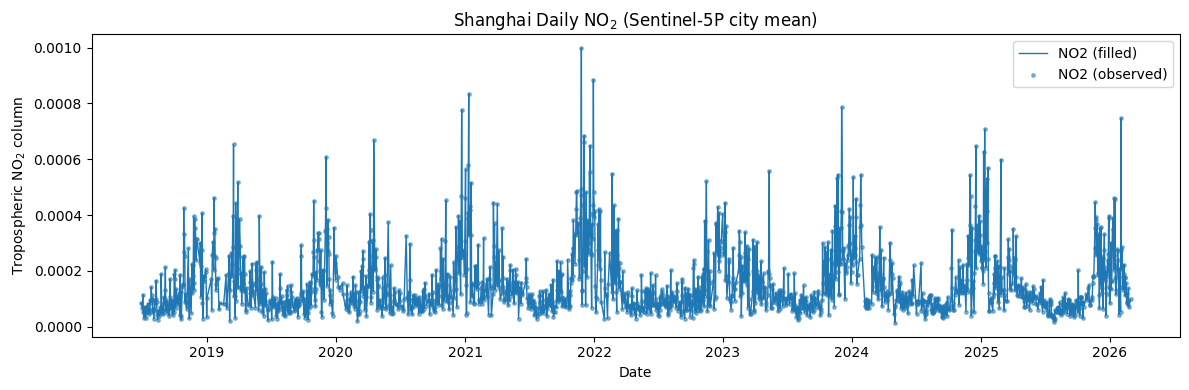

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2803 entries, 2018-06-28 to 2026-02-28
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   no2         2058 non-null   float64
 1   no2_filled  2803 non-null   float64
 2   year        2803 non-null   int32  
 3   month       2803 non-null   int32  
 4   dow         2803 non-null   int32  
dtypes: float64(2), int32(3)
memory usage: 98.5 KB


In [1869]:
df = df.sort_values("date")
df = df.set_index("date")

df["year"] = df.index.year
df["month"] = df.index.month
df["dow"] = df.index.dayofweek

plt.figure(figsize=(12,4))
plt.plot(df.index, df["no2_filled"], label="NO2 (filled)", linewidth=1)
plt.scatter(df.index, df["no2"], label="NO2 (observed)", s=6, alpha=0.5)
plt.title("Shanghai Daily NO$_2$ (Sentinel-5P city mean)")
plt.xlabel("Date")
plt.ylabel("Tropospheric NO$_2$ column")
plt.legend()
plt.tight_layout()
plt.show()

df.info()

Prepare NO2 Time Features

In [1870]:
if "date" not in df.columns:
    df = df.reset_index()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

input_series = df["no2_filled"].values
target_series = df["no2"].values

X, y, y_dates = [], [], []

for i in range(WINDOW, len(df)):
    if pd.notna(target_series[i]):
        X.append(input_series[i-WINDOW:i])
        y.append(target_series[i])
        y_dates.append(df["date"].iloc[i])

X = np.array(X)
y = np.array(y)
y_dates = pd.to_datetime(y_dates)

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (2034, 30)
Target shape: (2034,)


Train/Val/Test Split

In [1871]:
train_mask = y_dates <= "2022-12-31"
val_mask = (y_dates >= "2023-01-01") & (y_dates <= "2023-12-31")
test_mask = y_dates >= "2024-01-01"


X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
dates_test = y_dates[test_mask]


print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1162, 30)
Val: (275, 30)
Test: (597, 30)


Train Linear Regression

In [1872]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

val_pred = model.predict(X_val)

mae_val = mean_absolute_error(y_val, val_pred)
rmse_val = mean_squared_error(y_val, val_pred) ** 0.5
r2_val = r2_score(y_val, val_pred)

print("Validation MAE :", mae_val)
print("Validation RMSE:", rmse_val)
print("Validation R2  :", r2_val)

Validation MAE : 5.689165103120825e-05
Validation RMSE: 8.220371372775894e-05
Validation R2  : 0.39578820786901414


Evaluate Linear Regression

In [1873]:
lr_test_pred = model.predict(X_test)

lr_mae_test = mean_absolute_error(y_test, lr_test_pred)
lr_rmse_test = mean_squared_error(y_test, lr_test_pred) ** 0.5
lr_r2_test = r2_score(y_test, lr_test_pred)

results_table.loc[len(results_table)] = [
    "LR",
    WINDOW,
    "NO2",
    lr_mae_test,
    lr_rmse_test,
    lr_r2_test
]

results_table

,Model,Window,Features,MAE,RMSE,R2
0,LR,30,NO2,5.07520819e-05,8.01399547e-05,4.69352196e-01


Plot Linear Regression Results

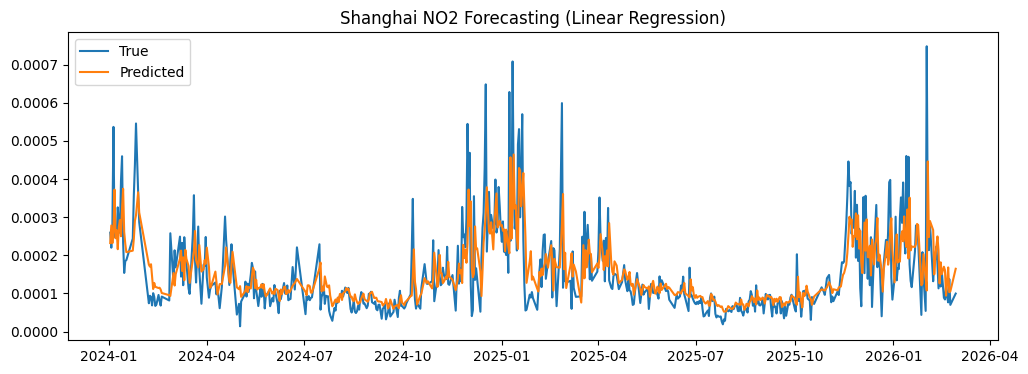

In [1874]:
plt.figure(figsize=(12,4))
plt.plot(dates_test, y_test, label="True")
plt.plot(dates_test, lr_test_pred, label="Predicted")
plt.legend()
plt.title("Shanghai NO2 Forecasting (Linear Regression)")
plt.show()

Prepare Sequences for LSTM

In [1875]:
if "date" not in df.columns:
    df = df.reset_index()

df = df.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df["has_obs"] = df["no2"].notna().astype(int)

df["month"] = df["date"].dt.month
df["dayofweek"] = df["date"].dt.dayofweek

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

feature_cols = [
    "no2_filled",
    "has_obs",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
]

data = df[feature_cols].to_numpy(dtype=np.float32)
target_real = df["no2"].to_numpy(dtype=np.float32)
dates = df["date"].to_numpy()

X_seq, y_seq, y_dates = [], [], []

for i in range(WINDOW, len(df)):
    if not np.isnan(target_real[i]):
        X_seq.append(data[i - WINDOW:i])
        y_seq.append(target_real[i])
        y_dates.append(dates[i])

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)
y_dates = pd.to_datetime(y_dates)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

train_mask = y_dates <= "2022-12-31"
val_mask = (y_dates >= "2023-01-01") & (y_dates <= "2023-12-31")
test_mask = y_dates >= "2024-01-01"

X_train, y_train = X_seq[train_mask], y_seq[train_mask]
X_val, y_val = X_seq[val_mask], y_seq[val_mask]
X_test, y_test = X_seq[test_mask], y_seq[test_mask]

dates_train = y_dates[train_mask]
dates_val = y_dates[val_mask]
dates_test = y_dates[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

X_seq shape: (2034, 30, 6)
y_seq shape: (2034,)
Train: (1162, 30, 6) (1162,)
Val  : (275, 30, 6) (275,)
Test : (597, 30, 6) (597,)


Scale LSTM Data

In [1876]:
from sklearn.preprocessing import StandardScaler

n_features = X_train.shape[2]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_val_2d = X_val.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

print(X_train_scaled.shape, y_train_scaled.shape)

(1162, 30, 6) (1162,)


LSTM Dataset and Model

In [1877]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SequenceDataset(X_train_scaled, y_train_scaled)
val_ds = SequenceDataset(X_val_scaled, y_val_scaled)
test_ds = SequenceDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        pred = self.fc(last_hidden).squeeze(-1)
        return pred

model = LSTMRegressor(input_size=n_features, hidden_size=64, num_layers=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using device: cpu


LSTM Evaluation

In [1878]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb)
            loss = criterion(out, yb)

            total_loss += loss.item() * xb.size(0)
            preds.append(out.cpu().numpy())
            targets.append(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return avg_loss, preds, targets

num_epochs = 50
best_val_loss = float("inf")
best_state = None
patience = 8
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * xb.size(0)

    train_loss = total_train_loss / len(train_loader.dataset)
    val_loss, _, _ = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_state)

Epoch 01 | train_loss=0.84209 | val_loss=0.55628
Epoch 02 | train_loss=0.70102 | val_loss=0.56938
Epoch 03 | train_loss=0.67511 | val_loss=0.55463
Epoch 04 | train_loss=0.65701 | val_loss=0.53905
Epoch 05 | train_loss=0.64183 | val_loss=0.52451
Epoch 06 | train_loss=0.63153 | val_loss=0.51391
Epoch 07 | train_loss=0.61371 | val_loss=0.50888
Epoch 08 | train_loss=0.59464 | val_loss=0.49874
Epoch 09 | train_loss=0.57270 | val_loss=0.49417
Epoch 10 | train_loss=0.55552 | val_loss=0.49856
Epoch 11 | train_loss=0.55404 | val_loss=0.49068
Epoch 12 | train_loss=0.53641 | val_loss=0.48666
Epoch 13 | train_loss=0.52685 | val_loss=0.49518
Epoch 14 | train_loss=0.51238 | val_loss=0.49305
Epoch 15 | train_loss=0.50801 | val_loss=0.48178
Epoch 16 | train_loss=0.50228 | val_loss=0.48745
Epoch 17 | train_loss=0.47783 | val_loss=0.49474
Epoch 18 | train_loss=0.48580 | val_loss=0.50100
Epoch 19 | train_loss=0.49620 | val_loss=0.46781
Epoch 20 | train_loss=0.47047 | val_loss=0.47142
Epoch 21 | train_los

<All keys matched successfully>

Evaluate LSTM

In [1879]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_loss, test_pred_scaled, test_true_scaled = evaluate(model, test_loader, criterion)

test_pred = y_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()
test_true = y_scaler.inverse_transform(test_true_scaled.reshape(-1, 1)).flatten()

lstm_mae = mean_absolute_error(test_true, test_pred)
lstm_rmse = mean_squared_error(test_true, test_pred) ** 0.5
lstm_r2 = r2_score(test_true, test_pred)

results_table.loc[len(results_table)] = [
    "LSTM",
    WINDOW,
    "NO2",
    lstm_mae,
    lstm_rmse,
    lstm_r2
]

results_table

,Model,Window,Features,MAE,RMSE,R2
0,LR,30,NO2,5.07520819e-05,8.01399547e-05,4.69352196e-01
1,LSTM,30,NO2,5.80770902e-05,9.07564590e-05,3.19444954e-01


Plot LSTM Results

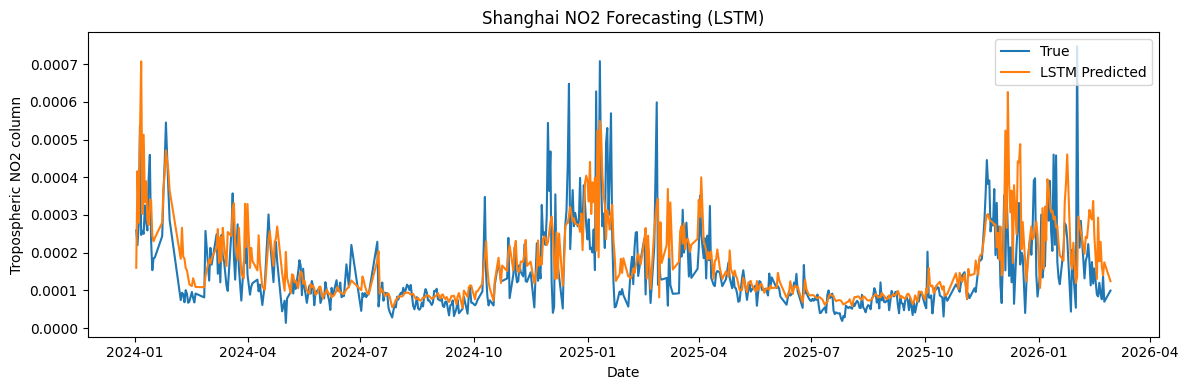

In [1880]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_true, label="True")
plt.plot(dates_test, test_pred, label="LSTM Predicted")
plt.legend()
plt.title("Shanghai NO2 Forecasting (LSTM)")
plt.xlabel("Date")
plt.ylabel("Tropospheric NO2 column")
plt.tight_layout()
plt.show()

1D-CNN Model

In [1881]:
import torch
import torch.nn as nn

class CNN1DRegressor(nn.Module):
    def __init__(self, input_size, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv_layers(x)
        x = self.fc_layers(x).squeeze(-1)
        return x

Initialize 1D-CNN

In [1882]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN1DRegressor(
    input_size=n_features,
    hidden_dim=64,
    dropout=0.2
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Train 1D-CNN

In [1883]:
num_epochs = 50
best_val_loss = float("inf")
best_state = None
patience = 8
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * xb.size(0)

    train_loss = total_train_loss / len(train_loader.dataset)
    val_loss, _, _ = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train_loss=0.88906 | val_loss=0.59552
Epoch 02 | train_loss=0.71263 | val_loss=0.57423
Epoch 03 | train_loss=0.72237 | val_loss=0.57072
Epoch 04 | train_loss=0.70257 | val_loss=0.56898
Epoch 05 | train_loss=0.70293 | val_loss=0.56438
Epoch 06 | train_loss=0.68675 | val_loss=0.56930
Epoch 07 | train_loss=0.68597 | val_loss=0.56709
Epoch 08 | train_loss=0.69395 | val_loss=0.56338
Epoch 09 | train_loss=0.68492 | val_loss=0.56780
Epoch 10 | train_loss=0.69078 | val_loss=0.56974
Epoch 11 | train_loss=0.70066 | val_loss=0.55901
Epoch 12 | train_loss=0.68351 | val_loss=0.55626
Epoch 13 | train_loss=0.68671 | val_loss=0.55741
Epoch 14 | train_loss=0.68107 | val_loss=0.56343
Epoch 15 | train_loss=0.67871 | val_loss=0.56177
Epoch 16 | train_loss=0.67638 | val_loss=0.56501
Epoch 17 | train_loss=0.68007 | val_loss=0.56393
Epoch 18 | train_loss=0.67705 | val_loss=0.55531
Epoch 19 | train_loss=0.66820 | val_loss=0.55675
Epoch 20 | train_loss=0.68683 | val_loss=0.54703
Epoch 21 | train_los

Evaluate 1D-CNN

In [1884]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_loss, test_pred_scaled, test_true_scaled = evaluate(model, test_loader, criterion)

test_pred = y_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()
test_true = y_scaler.inverse_transform(test_true_scaled.reshape(-1, 1)).flatten()

cnn_mae = mean_absolute_error(test_true, test_pred)
cnn_rmse = mean_squared_error(test_true, test_pred) ** 0.5
cnn_r2 = r2_score(test_true, test_pred)

results_table.loc[len(results_table)] = [
    "1D-CNN",
    WINDOW,
    "NO2",
    cnn_mae,
    cnn_rmse,
    cnn_r2
]

results_table

,Model,Window,Features,MAE,RMSE,R2
0,LR,30,NO2,5.07520819e-05,8.01399547e-05,4.69352196e-01
1,LSTM,30,NO2,5.80770902e-05,9.07564590e-05,3.19444954e-01
2,1D-CNN,30,NO2,5.67256866e-05,8.60280030e-05,3.88512075e-01


Plot 1D-CNN Results

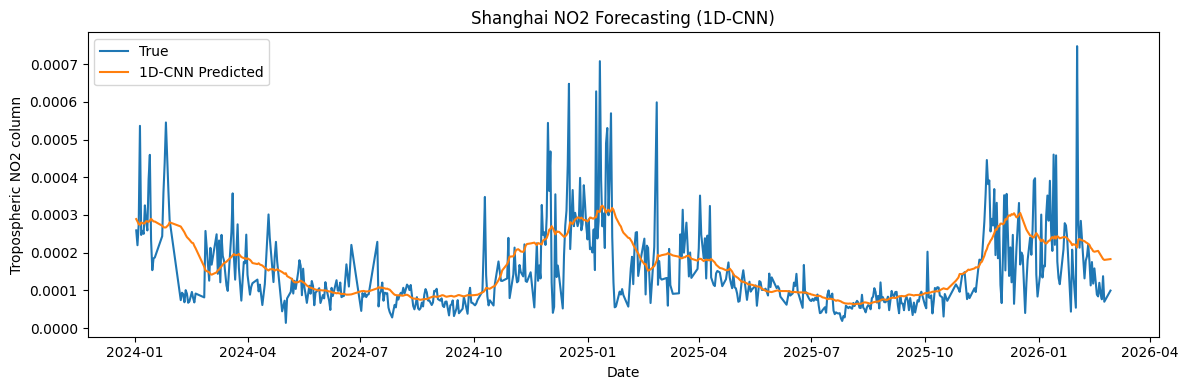

In [1885]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_true, label="True")
plt.plot(dates_test, test_pred, label="1D-CNN Predicted")
plt.legend()
plt.title("Shanghai NO2 Forecasting (1D-CNN)")
plt.xlabel("Date")
plt.ylabel("Tropospheric NO2 column")
plt.tight_layout()
plt.show()

Convert Data to Tensors

In [1886]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled.flatten(), dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val_scaled.flatten(), dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_scaled.flatten(), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train shape:", X_train_tensor.shape)
print("Val shape  :", X_val_tensor.shape)
print("Test shape :", X_test_tensor.shape)

Train shape: torch.Size([1162, 30, 6])
Val shape  : torch.Size([275, 30, 6])
Test shape : torch.Size([597, 30, 6])


L-TAE Model

In [1887]:
import math
import copy
import numpy as np
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


class LTAERegressor(nn.Module):
    def __init__(self, input_size, d_model=64, num_heads=4, ff_dim=128, dropout=0.2):
        super().__init__()

        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

        self.attn_pool = nn.Linear(d_model, 1)

        self.regressor = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)

        ff_out = self.ffn(x)
        x = self.norm2(x + ff_out)

        weights = torch.softmax(self.attn_pool(x), dim=1)
        context = (x * weights).sum(dim=1)

        out = self.regressor(context).squeeze(-1)
        return out

Using device: cpu


L-TAE Evaluation

In [1888]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb)
            loss = criterion(out, yb)

            total_loss += loss.item() * xb.size(0)
            preds.append(out.cpu().numpy())
            targets.append(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    return avg_loss, preds, targets

Initialize and Train L-TAE

In [1889]:
input_size = X_train_tensor.shape[2]

model = LTAERegressor(
    input_size=input_size,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
best_val_loss = float("inf")
best_state = None
patience = 8
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * xb.size(0)

    train_loss = total_train_loss / len(train_loader.dataset)
    val_loss, _, _ = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)

Epoch 01 | Train Loss: 0.744640 | Val Loss: 0.570277
Epoch 02 | Train Loss: 0.686931 | Val Loss: 0.523075
Epoch 03 | Train Loss: 0.641843 | Val Loss: 0.507745
Epoch 04 | Train Loss: 0.582129 | Val Loss: 0.467199
Epoch 05 | Train Loss: 0.559580 | Val Loss: 0.453277
Epoch 06 | Train Loss: 0.538697 | Val Loss: 0.460392
Epoch 07 | Train Loss: 0.558157 | Val Loss: 0.527256
Epoch 08 | Train Loss: 0.526818 | Val Loss: 0.453683
Epoch 09 | Train Loss: 0.510586 | Val Loss: 0.456557
Epoch 10 | Train Loss: 0.524099 | Val Loss: 0.457367
Epoch 11 | Train Loss: 0.489924 | Val Loss: 0.451691
Epoch 12 | Train Loss: 0.508822 | Val Loss: 0.533927
Epoch 13 | Train Loss: 0.500200 | Val Loss: 0.468234
Epoch 14 | Train Loss: 0.470186 | Val Loss: 0.500760
Epoch 15 | Train Loss: 0.466704 | Val Loss: 0.523925
Epoch 16 | Train Loss: 0.474616 | Val Loss: 0.485306
Epoch 17 | Train Loss: 0.471000 | Val Loss: 0.520952
Epoch 18 | Train Loss: 0.442014 | Val Loss: 0.522347
Epoch 19 | Train Loss: 0.455490 | Val Loss: 0.

<All keys matched successfully>

Evaluate L-TAE

In [1890]:
test_loss, test_pred_scaled, test_true_scaled = evaluate(model, test_loader, criterion)

test_pred = y_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()
test_true = y_scaler.inverse_transform(test_true_scaled.reshape(-1, 1)).flatten()

ltae_mae = mean_absolute_error(test_true, test_pred)
ltae_rmse = mean_squared_error(test_true, test_pred) ** 0.5
ltae_r2 = r2_score(test_true, test_pred)

results_table.loc[len(results_table)] = [
    "L-TAE",
    WINDOW,
    "NO2",
    ltae_mae,
    ltae_rmse,
    ltae_r2
]

results_table

,Model,Window,Features,MAE,RMSE,R2
0,LR,30,NO2,5.07520819e-05,8.01399547e-05,4.69352196e-01
1,LSTM,30,NO2,5.80770902e-05,9.07564590e-05,3.19444954e-01
2,1D-CNN,30,NO2,5.67256866e-05,8.60280030e-05,3.88512075e-01
3,L-TAE,30,NO2,4.91354876e-05,7.58955505e-05,5.24072468e-01


Plot L-TAE Results

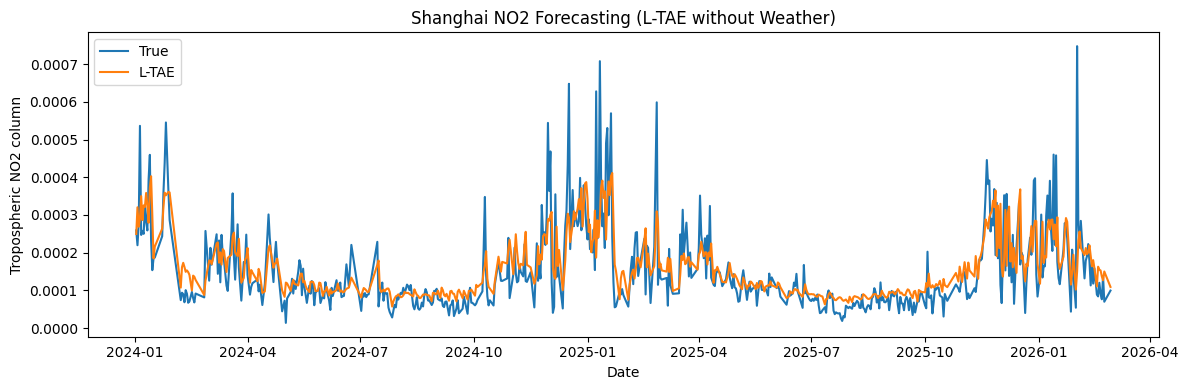

In [1891]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_true, label="True")
plt.plot(dates_test, test_pred, label="L-TAE")
plt.legend()
plt.title("Shanghai NO2 Forecasting (L-TAE without Weather)")
plt.xlabel("Date")
plt.ylabel("Tropospheric NO2 column")
plt.tight_layout()
plt.show()

Set Weather Region

In [1892]:
region = ee.Geometry.Rectangle([120.9, 30.7, 122.1, 31.9])

start_date = '2018-06-28'
end_date = '2026-03-01'

era5 = (
    ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
    .filterDate(start_date, end_date)
)

def image_to_feature(img):
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=10000,
        bestEffort=True
    )
    
    return ee.Feature(
        None,
        stats.set('date', img.date().format('YYYY-MM-dd'))
    )

weather_fc = era5.map(image_to_feature)

weather_dict = weather_fc.getInfo()

rows = [f['properties'] for f in weather_dict['features']]

weather_df = pd.DataFrame(rows)
weather_df['date'] = pd.to_datetime(weather_df['date'])

print(weather_df.shape)
weather_df.head()

(2803, 151)


,date,dewpoint_temperature_2m,dewpoint_temperature_2m_max,dewpoint_temperature_2m_min,evaporation_from_bare_soil_max,evaporation_from_bare_soil_min,evaporation_from_bare_soil_sum,evaporation_from_open_water_surfaces_excluding_oceans_max,evaporation_from_open_water_surfaces_excluding_oceans_min,evaporation_from_open_water_surfaces_excluding_oceans_sum,...,volumetric_soil_water_layer_1_min,volumetric_soil_water_layer_2,volumetric_soil_water_layer_2_max,volumetric_soil_water_layer_2_min,volumetric_soil_water_layer_3,volumetric_soil_water_layer_3_max,volumetric_soil_water_layer_3_min,volumetric_soil_water_layer_4,volumetric_soil_water_layer_4_max,volumetric_soil_water_layer_4_min
0,2018-06-28,2.97776548e+02,2.98775379e+02,2.96965334e+02,-4.10422608e-10,-3.29673307e-04,-2.14975307e-03,5.82983945e-07,-8.55232611e-05,-5.67728188e-04,...,2.81173739e-01,3.21352261e-01,3.51261882e-01,3.06416093e-01,3.12426715e-01,3.13374948e-01,3.12126376e-01,3.49886966e-01,3.49977927e-01,3.49827991e-01
1,2018-06-29,2.97826752e+02,2.98500343e+02,2.97110733e+02,-7.49120876e-10,-3.62229885e-04,-2.32825186e-03,5.72556180e-08,-1.22097683e-04,-7.57918051e-04,...,3.53383349e-01,3.50912432e-01,3.76028765e-01,3.46454673e-01,3.12814122e-01,3.13596145e-01,3.12334857e-01,3.49737019e-01,3.49826722e-01,3.49676659e-01
2,2018-06-30,2.97881526e+02,2.98523131e+02,2.97395176e+02,-3.41900178e-08,-1.42456221e-05,-5.29588338e-05,-1.08016894e-07,-7.54555824e-06,-4.37499045e-05,...,3.97780347e-01,3.99176173e-01,4.13760016e-01,3.78196615e-01,3.20418278e-01,3.27530702e-01,3.13682610e-01,3.49637566e-01,3.49683135e-01,3.49600761e-01
3,2018-07-01,2.97682782e+02,2.98023653e+02,2.97023794e+02,-9.03733198e-08,-1.90120759e-04,-7.88488702e-04,3.36991866e-08,-9.14595189e-05,-3.80278963e-04,...,3.91581701e-01,3.99796510e-01,4.06800147e-01,3.93423200e-01,3.33291856e-01,3.37092564e-01,3.28190375e-01,3.49583996e-01,3.49626092e-01,3.49552888e-01
4,2018-07-02,2.97315195e+02,2.98016174e+02,2.96699802e+02,-4.38994444e-07,-2.98492830e-04,-2.01494700e-03,-4.21016636e-07,-9.55418941e-05,-6.59590015e-04,...,3.73615453e-01,3.84397003e-01,3.92866838e-01,3.79096851e-01,3.38618655e-01,3.39945961e-01,3.37286926e-01,3.49544529e-01,3.49601132e-01,3.49509862e-01


Rename Weather Columns

In [1893]:
weather_df["date"] = pd.to_datetime(weather_df["date"])

weather_df = weather_df.rename(columns={
    "temperature_2m": "temp_mean",
    "temperature_2m_min": "temp_min",
    "temperature_2m_max": "temp_max",
    "dewpoint_temperature_2m": "dewpoint",
    "total_precipitation_sum": "precip",
    "u_component_of_wind_10m": "u10",
    "v_component_of_wind_10m": "v10"
})

keep_cols = [
    "date",
    "temp_mean",
    "temp_min",
    "temp_max",
    "dewpoint",
    "precip",
    "surface_pressure",
    "u10",
    "v10"
]

weather_df = weather_df[keep_cols].copy()
weather_df.head()

,date,temp_mean,temp_min,temp_max,dewpoint,precip,surface_pressure,u10,v10
0,2018-06-28,3.01193824e+02,2.97665304e+02,3.05694079e+02,2.97776548e+02,1.93463728e-02,1.00042113e+05,2.07858281e+00,1.07994232e+00
1,2018-06-29,3.00550813e+02,2.98084830e+02,3.03823195e+02,2.97826752e+02,1.41611284e-02,1.00169003e+05,-9.71354235e-01,1.83094816e+00
2,2018-06-30,2.99229535e+02,2.98621767e+02,3.00204171e+02,2.97881526e+02,2.07739740e-02,1.00362469e+05,-1.86399122e+00,4.07609388e+00
3,2018-07-01,2.99706571e+02,2.98482104e+02,3.01606264e+02,2.97682782e+02,5.73819173e-03,1.00289841e+05,-2.31201119e+00,3.26361019e+00
4,2018-07-02,2.99742157e+02,2.97716286e+02,3.02149337e+02,2.97315195e+02,1.30373771e-03,1.00015109e+05,-3.05137061e+00,1.27723757e+00


Create Weather Features

In [1894]:
weather_df["wind_speed"] = np.sqrt(weather_df["u10"]**2 + weather_df["v10"]**2)

weather_df["temp_mean_C"] = weather_df["temp_mean"] - 273.15
weather_df["temp_min_C"] = weather_df["temp_min"] - 273.15
weather_df["temp_max_C"] = weather_df["temp_max"] - 273.15
weather_df["dewpoint_C"] = weather_df["dewpoint"] - 273.15

weather_df["precip_mm"] = weather_df["precip"] * 1000

T = weather_df["temp_mean_C"]
Td = weather_df["dewpoint_C"]

weather_df["rel_humidity"] = (
    100 * np.exp((17.625 * Td) / (243.04 + Td)) /
    np.exp((17.625 * T) / (243.04 + T))
)

weather_df = weather_df[
    [
        "date",
        "temp_mean_C",
        "temp_min_C",
        "temp_max_C",
        "dewpoint_C",
        "precip_mm",
        "surface_pressure",
        "wind_speed",
        "rel_humidity",
    ]
]

weather_df.head()

,date,temp_mean_C,temp_min_C,temp_max_C,dewpoint_C,precip_mm,surface_pressure,wind_speed,rel_humidity
0,2018-06-28,2.80438237e+01,2.45153044e+01,3.25440793e+01,2.46265476e+01,1.93463728e+01,1.00042113e+05,2.34238808e+00,8.17308450e+01
1,2018-06-29,2.74008132e+01,2.49348297e+01,3.06731952e+01,2.46767520e+01,1.41611284e+01,1.00169003e+05,2.07265536e+00,8.51149969e+01
2,2018-06-30,2.60795348e+01,2.54717675e+01,2.70541713e+01,2.47315261e+01,2.07739740e+01,1.00362469e+05,4.48207592e+00,9.22997231e+01
3,2018-07-01,2.65565706e+01,2.53321035e+01,2.84562644e+01,2.45327822e+01,5.73819173e+00,1.00289841e+05,3.99956838e+00,8.86764859e+01
4,2018-07-02,2.65921573e+01,2.45662857e+01,2.89993368e+01,2.41651948e+01,1.30373771e+00,1.00015109e+05,3.30789939e+00,8.65631746e+01


Merge NO2 and Weather Data

In [1895]:
df["date"] = pd.to_datetime(df["date"])
weather_df["date"] = pd.to_datetime(weather_df["date"])

df_merged = pd.merge(df, weather_df, on="date", how="left")
df_merged = df_merged.sort_values("date").reset_index(drop=True)

keep_cols = [
    "date",
    "no2",
    "no2_filled",
    "has_obs",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "temp_mean_C",
    "dewpoint_C",
    "precip_mm",
    "surface_pressure",
    "wind_speed",
    "rel_humidity",
]

df_merged = df_merged[keep_cols].copy()
df_merged.head()

,date,no2,no2_filled,has_obs,month_sin,month_cos,dow_sin,dow_cos,temp_mean_C,dewpoint_C,precip_mm,surface_pressure,wind_speed,rel_humidity
0,2018-06-28,NaN,8.50918020e-05,0,1.22464680e-16,-1.00000000e+00,4.33883739e-01,-9.00968868e-01,2.80438237e+01,2.46265476e+01,1.93463728e+01,1.00042113e+05,2.34238808e+00,8.17308450e+01
1,2018-06-29,8.50918020e-05,8.50918020e-05,1,1.22464680e-16,-1.00000000e+00,-4.33883739e-01,-9.00968868e-01,2.74008132e+01,2.46767520e+01,1.41611284e+01,1.00169003e+05,2.07265536e+00,8.51149969e+01
2,2018-06-30,NaN,7.90050162e-05,0,1.22464680e-16,-1.00000000e+00,-9.74927912e-01,-2.22520934e-01,2.60795348e+01,2.47315261e+01,2.07739740e+01,1.00362469e+05,4.48207592e+00,9.22997231e+01
3,2018-07-01,NaN,7.29182304e-05,0,-5.00000000e-01,-8.66025404e-01,-7.81831482e-01,6.23489802e-01,2.65565706e+01,2.45327822e+01,5.73819173e+00,1.00289841e+05,3.99956838e+00,8.86764859e+01
4,2018-07-02,6.68314446e-05,6.68314446e-05,1,-5.00000000e-01,-8.66025404e-01,0.00000000e+00,1.00000000e+00,2.65921573e+01,2.41651948e+01,1.30373771e+00,1.00015109e+05,3.30789939e+00,8.65631746e+01


Select Weather Variables

In [1896]:
weather_cols = [
    "temp_mean_C",
    "dewpoint_C",
    "precip_mm",
    "surface_pressure",
    "wind_speed",
    "rel_humidity"
]

df_merged[weather_cols] = df_merged[weather_cols].interpolate(method="linear")
df_merged[weather_cols] = df_merged[weather_cols].bfill().ffill()

Add Cyclical Time Features

In [1897]:
df_merged["month"] = df_merged["date"].dt.month
df_merged["dayofweek"] = df_merged["date"].dt.dayofweek

df_merged["month_sin"] = np.sin(2 * np.pi * df_merged["month"] / 12)
df_merged["month_cos"] = np.cos(2 * np.pi * df_merged["month"] / 12)
df_merged["dow_sin"] = np.sin(2 * np.pi * df_merged["dayofweek"] / 7)
df_merged["dow_cos"] = np.cos(2 * np.pi * df_merged["dayofweek"] / 7)

Final Feature Columns

In [1898]:
feature_cols = [
    "no2_filled",
    "has_obs",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "temp_mean_C",
    "dewpoint_C",
    "precip_mm",
    "surface_pressure",
    "wind_speed",
    "rel_humidity"
]

target_col = "no2"

print("Using features:", feature_cols)

Using features: ['no2_filled', 'has_obs', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'temp_mean_C', 'dewpoint_C', 'precip_mm', 'surface_pressure', 'wind_speed', 'rel_humidity']


Weather Sequences

In [1899]:
data = df_merged[feature_cols].values.astype(np.float32)
target = df_merged[target_col].values.astype(np.float32)
dates = pd.to_datetime(df_merged["date"])

X_seq, y_seq, y_dates = [], [], []

for i in range(WINDOW, len(df_merged)):
    window_data = data[i-WINDOW:i]

    if np.isfinite(target[i]) and np.all(np.isfinite(window_data)):
        X_seq.append(window_data)
        y_seq.append(target[i])
        y_dates.append(dates.iloc[i])

X_seq = np.array(X_seq, dtype=np.float32)
y_seq = np.array(y_seq, dtype=np.float32)
y_dates = pd.to_datetime(y_dates)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (2034, 30, 12)
y_seq shape: (2034,)


Weather Train/Val/Test

In [1900]:
train_mask = y_dates <= "2022-12-31"
val_mask = (y_dates >= "2023-01-01") & (y_dates <= "2023-12-31")
test_mask = y_dates >= "2024-01-01"

X_train, y_train = X_seq[train_mask], y_seq[train_mask]
X_val, y_val = X_seq[val_mask], y_seq[val_mask]
X_test, y_test = X_seq[test_mask], y_seq[test_mask]

dates_train = y_dates[train_mask]
dates_val = y_dates[val_mask]
dates_test = y_dates[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1162, 30, 12) (1162,)
Val  : (275, 30, 12) (275,)
Test : (597, 30, 12) (597,)


Train Linear Regression with Weather

In [1901]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train_lr = X_train.reshape(X_train.shape[0], -1)
X_val_lr   = X_val.reshape(X_val.shape[0], -1)
X_test_lr  = X_test.reshape(X_test.shape[0], -1)

print("X_train_lr:", X_train_lr.shape)
print("X_val_lr  :", X_val_lr.shape)
print("X_test_lr :", X_test_lr.shape)

lr_weather_model = LinearRegression()
lr_weather_model.fit(X_train_lr, y_train)

val_pred = lr_weather_model.predict(X_val_lr)

mae_val = mean_absolute_error(y_val, val_pred)
rmse_val = mean_squared_error(y_val, val_pred) ** 0.5
r2_val = r2_score(y_val, val_pred)

print("Validation MAE :", mae_val)
print("Validation RMSE:", rmse_val)
print("Validation R2  :", r2_val)

X_train_lr: (1162, 360)
X_val_lr  : (275, 360)
X_test_lr : (597, 360)
Validation MAE : 6.484756158897653e-05
Validation RMSE: 8.98851135981315e-05
Validation R2  : 0.27759307622909546


In [1902]:
lr_weather_pred = lr_weather_model.predict(X_test_lr)

lr_weather_mae = mean_absolute_error(y_test, lr_weather_pred)
lr_weather_rmse = mean_squared_error(y_test, lr_weather_pred) ** 0.5
lr_weather_r2 = r2_score(y_test, lr_weather_pred)

print("\nTest MAE :", lr_weather_mae)
print("Test RMSE:", lr_weather_rmse)
print("Test R2  :", lr_weather_r2)

results_table.loc[len(results_table)] = [
    "LR",
    WINDOW,
    "NO2 + Weather",
    lr_weather_mae,
    lr_weather_rmse,
    lr_weather_r2
]

results_table


Test MAE : 6.600072811124846e-05
Test RMSE: 9.095728846354238e-05
Test R2  : 0.31642967462539673


,Model,Window,Features,MAE,RMSE,R2
0,LR,30,NO2,5.07520819e-05,8.01399547e-05,4.69352196e-01
1,LSTM,30,NO2,5.80770902e-05,9.07564590e-05,3.19444954e-01
2,1D-CNN,30,NO2,5.67256866e-05,8.60280030e-05,3.88512075e-01
3,L-TAE,30,NO2,4.91354876e-05,7.58955505e-05,5.24072468e-01
4,LR,30,NO2 + Weather,6.60007281e-05,9.09572885e-05,3.16429675e-01


Plot Weather Linear Regression

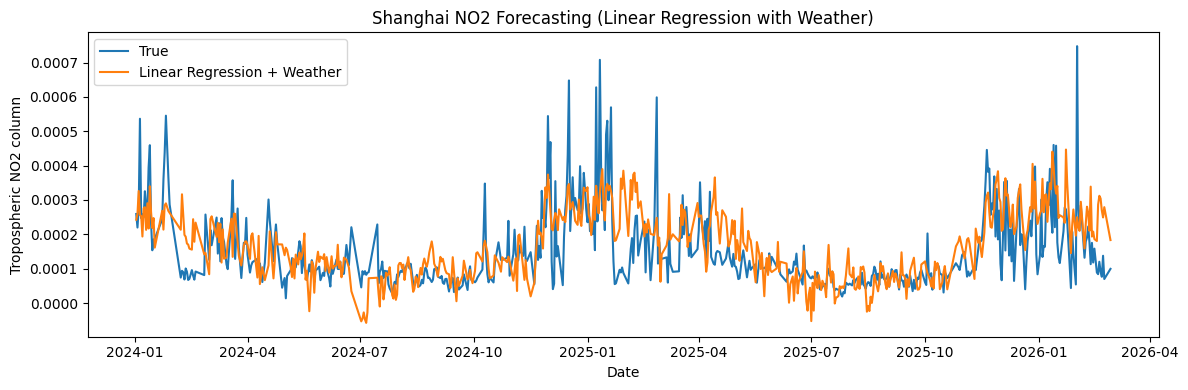

In [1903]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test, y_test, label="True")
plt.plot(dates_test, lr_weather_pred, label="Linear Regression + Weather")
plt.legend()
plt.title("Shanghai NO2 Forecasting (Linear Regression with Weather)")
plt.xlabel("Date")
plt.ylabel("Tropospheric NO2 column")
plt.tight_layout()
plt.show()

Scale Weather Sequence Data

In [1904]:
from sklearn.preprocessing import StandardScaler

n_features = X_train.shape[2]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_val_2d = X_val.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

print(X_train_scaled.shape, y_train_scaled.shape)

(1162, 30, 12) (1162,)


Build Weather Dataset

In [1905]:
import torch
from torch.utils.data import Dataset, DataLoader

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SequenceDataset(X_train_scaled, y_train_scaled)
val_ds = SequenceDataset(X_val_scaled, y_val_scaled)
test_ds = SequenceDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

Train Weather LSTM

In [1906]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        pred = self.fc(last_hidden).squeeze(-1)
        return pred

model = LSTMRegressor(input_size=n_features, hidden_size=64, num_layers=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using device: cpu


Weather LSTM Evaluation

In [1907]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb)
            loss = criterion(out, yb)

            total_loss += loss.item() * xb.size(0)
            preds.append(out.cpu().numpy())
            targets.append(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return avg_loss, preds, targets

num_epochs = 50
best_val_loss = float("inf")
best_state = None
patience = 8
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * xb.size(0)

    train_loss = total_train_loss / len(train_loader.dataset)
    val_loss, _, _ = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping")
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train_loss=0.84519 | val_loss=0.57049
Epoch 02 | train_loss=0.71593 | val_loss=0.57607
Epoch 03 | train_loss=0.66664 | val_loss=0.62936
Epoch 04 | train_loss=0.64659 | val_loss=0.56762
Epoch 05 | train_loss=0.62229 | val_loss=0.54525
Epoch 06 | train_loss=0.60068 | val_loss=0.52449
Epoch 07 | train_loss=0.58210 | val_loss=0.50762
Epoch 08 | train_loss=0.56006 | val_loss=0.49533
Epoch 09 | train_loss=0.54246 | val_loss=0.49969
Epoch 10 | train_loss=0.52415 | val_loss=0.51450
Epoch 11 | train_loss=0.51868 | val_loss=0.49980
Epoch 12 | train_loss=0.50669 | val_loss=0.47593
Epoch 13 | train_loss=0.49299 | val_loss=0.50158
Epoch 14 | train_loss=0.49072 | val_loss=0.46753
Epoch 15 | train_loss=0.48487 | val_loss=0.48011
Epoch 16 | train_loss=0.46000 | val_loss=0.48760
Epoch 17 | train_loss=0.45436 | val_loss=0.45066
Epoch 18 | train_loss=0.44736 | val_loss=0.49913
Epoch 19 | train_loss=0.41888 | val_loss=0.48737
Epoch 20 | train_loss=0.42309 | val_loss=0.46655
Epoch 21 | train_los

Evaluate Weather LSTM

In [1908]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_loss, test_pred_scaled, test_true_scaled = evaluate(model, test_loader, criterion)

test_pred = y_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()
test_true = y_scaler.inverse_transform(test_true_scaled.reshape(-1, 1)).flatten()

lstm_mae = mean_absolute_error(test_true, test_pred)
lstm_rmse = mean_squared_error(test_true, test_pred) ** 0.5
lstm_r2 = r2_score(test_true, test_pred)

results_table.loc[len(results_table)] = [
    "LSTM",
    WINDOW,
    "NO2 + Weather",
    lstm_mae,
    lstm_rmse,
    lstm_r2
]

results_table

,Model,Window,Features,MAE,RMSE,R2
0,LR,30,NO2,5.07520819e-05,8.01399547e-05,4.69352196e-01
1,LSTM,30,NO2,5.80770902e-05,9.07564590e-05,3.19444954e-01
2,1D-CNN,30,NO2,5.67256866e-05,8.60280030e-05,3.88512075e-01
3,L-TAE,30,NO2,4.91354876e-05,7.58955505e-05,5.24072468e-01
4,LR,30,NO2 + Weather,6.60007281e-05,9.09572885e-05,3.16429675e-01
5,LSTM,30,NO2 + Weather,5.35571962e-05,8.30850960e-05,4.29632902e-01


Plot Weather LSTM Results

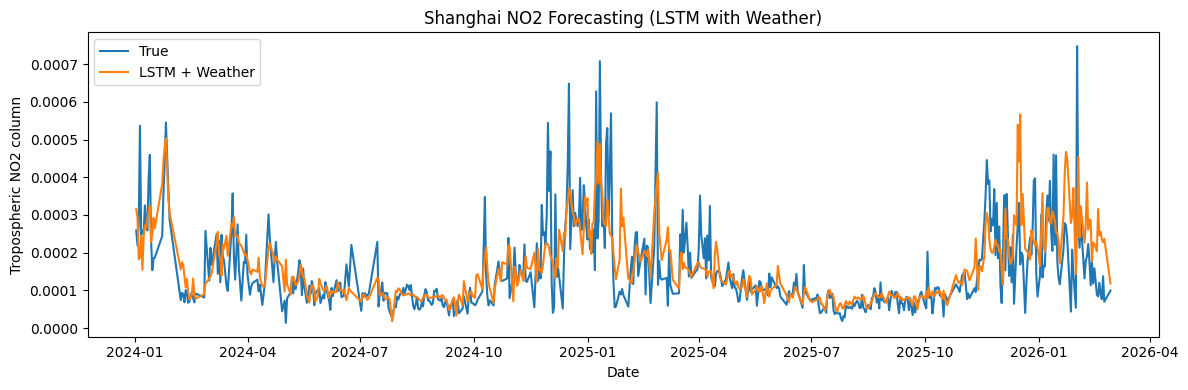

In [1909]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_true, label="True")
plt.plot(dates_test, test_pred, label="LSTM + Weather")
plt.legend()
plt.title("Shanghai NO2 Forecasting (LSTM with Weather)")
plt.xlabel("Date")
plt.ylabel("Tropospheric NO2 column")
plt.tight_layout()
plt.show()

Define Weather 1D-CNN

In [1910]:
class CNN1DRegressor(nn.Module):
    def __init__(self, input_size, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels=input_size, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.features(x)
        x = self.regressor(x).squeeze(-1)
        return x

Train Weather 1D-CNN

In [1911]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = CNN1DRegressor(
    input_size=n_features,
    hidden_dim=64,
    dropout=0.2
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using device: cpu


Weather CNN Evaluation

In [1912]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb)
            loss = criterion(out, yb)

            total_loss += loss.item() * xb.size(0)
            preds.append(out.cpu().numpy())
            targets.append(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return avg_loss, preds, targets


num_epochs = 50
best_val_loss = float("inf")
best_state = None
patience = 8
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * xb.size(0)

    train_loss = total_train_loss / len(train_loader.dataset)
    val_loss, _, _ = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping")
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train_loss=0.89165 | val_loss=0.60070
Epoch 02 | train_loss=0.73514 | val_loss=0.58884
Epoch 03 | train_loss=0.71586 | val_loss=0.60975
Epoch 04 | train_loss=0.70256 | val_loss=0.59874
Epoch 05 | train_loss=0.70285 | val_loss=0.58915
Epoch 06 | train_loss=0.70064 | val_loss=0.57255
Epoch 07 | train_loss=0.68930 | val_loss=0.58218
Epoch 08 | train_loss=0.68618 | val_loss=0.57348
Epoch 09 | train_loss=0.69199 | val_loss=0.57819
Epoch 10 | train_loss=0.67293 | val_loss=0.57883
Epoch 11 | train_loss=0.68161 | val_loss=0.56886
Epoch 12 | train_loss=0.67081 | val_loss=0.57336
Epoch 13 | train_loss=0.66423 | val_loss=0.57864
Epoch 14 | train_loss=0.67087 | val_loss=0.56028
Epoch 15 | train_loss=0.67214 | val_loss=0.56264
Epoch 16 | train_loss=0.64591 | val_loss=0.57600
Epoch 17 | train_loss=0.64992 | val_loss=0.57013
Epoch 18 | train_loss=0.63629 | val_loss=0.58391
Epoch 19 | train_loss=0.62433 | val_loss=0.57801
Epoch 20 | train_loss=0.63001 | val_loss=0.56304
Epoch 21 | train_los

Evaluate Weather 1D-CNN

In [1913]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_loss, test_pred_scaled, test_true_scaled = evaluate(model, test_loader, criterion)

test_pred = y_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()
test_true = y_scaler.inverse_transform(test_true_scaled.reshape(-1, 1)).flatten()

cnn_mae = mean_absolute_error(test_true, test_pred)
cnn_rmse = mean_squared_error(test_true, test_pred) ** 0.5
cnn_r2 = r2_score(test_true, test_pred)

results_table.loc[len(results_table)] = [
    "1D-CNN",
    WINDOW,
    "NO2 + Weather",
    cnn_mae,
    cnn_rmse,
    cnn_r2
]

results_table

,Model,Window,Features,MAE,RMSE,R2
0,LR,30,NO2,5.07520819e-05,8.01399547e-05,4.69352196e-01
1,LSTM,30,NO2,5.80770902e-05,9.07564590e-05,3.19444954e-01
2,1D-CNN,30,NO2,5.67256866e-05,8.60280030e-05,3.88512075e-01
3,L-TAE,30,NO2,4.91354876e-05,7.58955505e-05,5.24072468e-01
4,LR,30,NO2 + Weather,6.60007281e-05,9.09572885e-05,3.16429675e-01
5,LSTM,30,NO2 + Weather,5.35571962e-05,8.30850960e-05,4.29632902e-01
6,1D-CNN,30,NO2 + Weather,5.88472831e-05,9.64344163e-05,2.31626630e-01


Plot Weather 1D-CNN Results

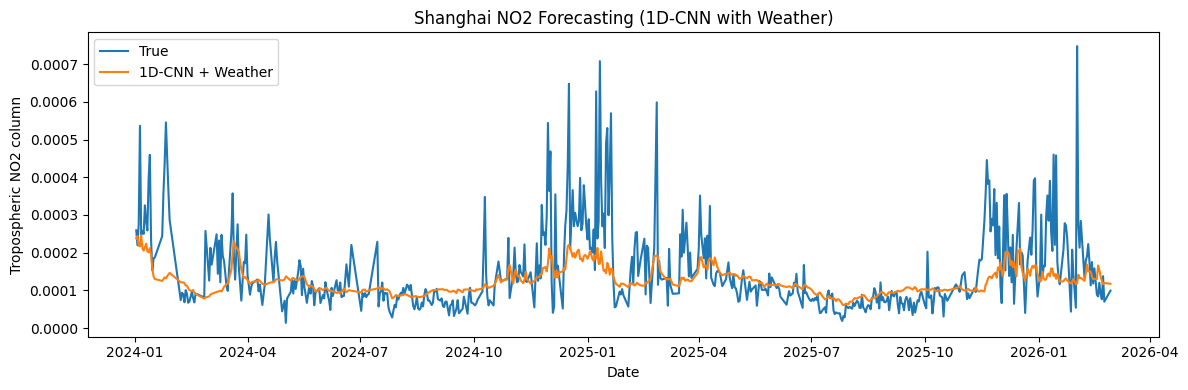

In [1914]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_true, label="True")
plt.plot(dates_test, test_pred, label="1D-CNN + Weather")
plt.legend()
plt.title("Shanghai NO2 Forecasting (1D-CNN with Weather)")
plt.xlabel("Date")
plt.ylabel("Tropospheric NO2 column")
plt.tight_layout()
plt.show()

Define Weather L-TAE

In [1915]:
import math
import copy
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]


class LTAERegressor(nn.Module):
    def __init__(
        self,
        input_size,
        d_model=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.2
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model)
        )

        self.attn_pool = nn.Linear(d_model, 1)

        self.regressor = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)

        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_out)

        ff_out = self.ffn(x)
        x = self.norm2(x + ff_out)

        weights = torch.softmax(self.attn_pool(x), dim=1)
        context = (x * weights).sum(dim=1)

        out = self.regressor(context).squeeze(-1)
        return out

Using device: cpu


Weather L-TAE Evaluation

In [1916]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb)
            loss = criterion(out, yb)

            total_loss += loss.item() * xb.size(0)
            preds.append(out.cpu().numpy())
            targets.append(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return avg_loss, preds, targets


model = LTAERegressor(
    input_size=n_features,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
best_val_loss = float("inf")
best_state = None
patience = 8
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * xb.size(0)

    train_loss = total_train_loss / len(train_loader.dataset)
    val_loss, _, _ = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)

Epoch 01 | Train Loss: 0.847327 | Val Loss: 0.558207
Epoch 02 | Train Loss: 0.739911 | Val Loss: 0.587821
Epoch 03 | Train Loss: 0.716237 | Val Loss: 0.570228
Epoch 04 | Train Loss: 0.695806 | Val Loss: 0.545273
Epoch 05 | Train Loss: 0.626092 | Val Loss: 0.558482
Epoch 06 | Train Loss: 0.576868 | Val Loss: 0.483176
Epoch 07 | Train Loss: 0.545822 | Val Loss: 0.496307
Epoch 08 | Train Loss: 0.540855 | Val Loss: 0.493437
Epoch 09 | Train Loss: 0.522588 | Val Loss: 0.459754
Epoch 10 | Train Loss: 0.509145 | Val Loss: 0.544153
Epoch 11 | Train Loss: 0.482834 | Val Loss: 0.511129
Epoch 12 | Train Loss: 0.488299 | Val Loss: 0.580771
Epoch 13 | Train Loss: 0.475944 | Val Loss: 0.435004
Epoch 14 | Train Loss: 0.475997 | Val Loss: 0.621845
Epoch 15 | Train Loss: 0.483585 | Val Loss: 0.445133
Epoch 16 | Train Loss: 0.461460 | Val Loss: 0.656439
Epoch 17 | Train Loss: 0.466593 | Val Loss: 0.788516
Epoch 18 | Train Loss: 0.461300 | Val Loss: 0.455097
Epoch 19 | Train Loss: 0.529125 | Val Loss: 0.

<All keys matched successfully>

Evaluate Weather L-TAE

In [1917]:
test_loss, test_pred_scaled, test_true_scaled = evaluate(model, test_loader, criterion)

test_pred = y_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()
test_true = y_scaler.inverse_transform(test_true_scaled.reshape(-1, 1)).flatten()

ltae_mae = mean_absolute_error(test_true, test_pred)
ltae_rmse = mean_squared_error(test_true, test_pred) ** 0.5
ltae_r2 = r2_score(test_true, test_pred)

results_table.loc[len(results_table)] = [
    "L-TAE",
    WINDOW,
    "NO2 + Weather",
    ltae_mae,
    ltae_rmse,
    ltae_r2
]

results_table

,Model,Window,Features,MAE,RMSE,R2
0,LR,30,NO2,5.07520819e-05,8.01399547e-05,4.69352196e-01
1,LSTM,30,NO2,5.80770902e-05,9.07564590e-05,3.19444954e-01
2,1D-CNN,30,NO2,5.67256866e-05,8.60280030e-05,3.88512075e-01
3,L-TAE,30,NO2,4.91354876e-05,7.58955505e-05,5.24072468e-01
4,LR,30,NO2 + Weather,6.60007281e-05,9.09572885e-05,3.16429675e-01
5,LSTM,30,NO2 + Weather,5.35571962e-05,8.30850960e-05,4.29632902e-01
6,1D-CNN,30,NO2 + Weather,5.88472831e-05,9.64344163e-05,2.31626630e-01
7,L-TAE,30,NO2 + Weather,4.68187754e-05,7.32183624e-05,5.57056665e-01


Plot Weather L-TAE Results

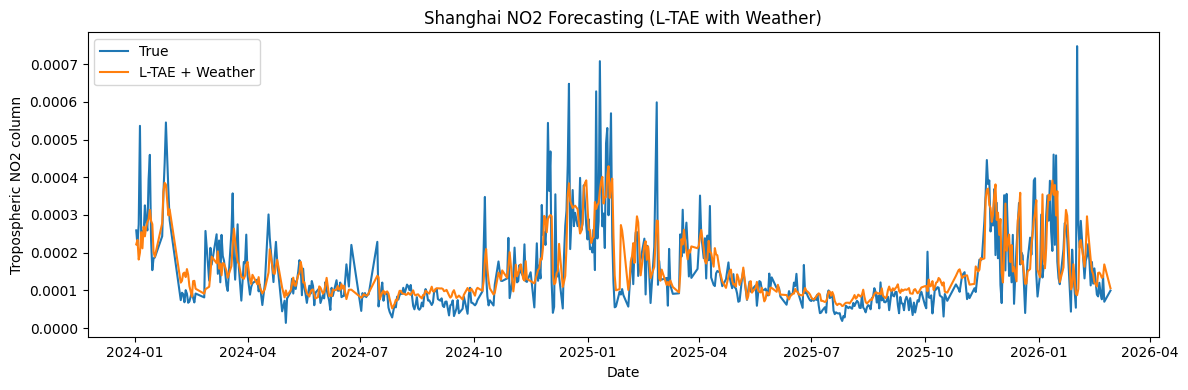

In [1918]:
plt.figure(figsize=(12, 4))
plt.plot(dates_test, test_true, label="True")
plt.plot(dates_test, test_pred, label="L-TAE + Weather")
plt.legend()
plt.title("Shanghai NO2 Forecasting (L-TAE with Weather)")
plt.xlabel("Date")
plt.ylabel("Tropospheric NO2 column")
plt.tight_layout()
plt.show()

Sort Results Table

In [1919]:
results_sorted = results_table.sort_values(by="RMSE", ascending=True)

results_sorted.reset_index(drop=True, inplace=True)

results_sorted

,Model,Window,Features,MAE,RMSE,R2
0,L-TAE,30,NO2 + Weather,4.68187754e-05,7.32183624e-05,5.57056665e-01
1,L-TAE,30,NO2,4.91354876e-05,7.58955505e-05,5.24072468e-01
2,LR,30,NO2,5.07520819e-05,8.01399547e-05,4.69352196e-01
3,LSTM,30,NO2 + Weather,5.35571962e-05,8.30850960e-05,4.29632902e-01
4,1D-CNN,30,NO2,5.67256866e-05,8.60280030e-05,3.88512075e-01
5,LSTM,30,NO2,5.80770902e-05,9.07564590e-05,3.19444954e-01
6,LR,30,NO2 + Weather,6.60007281e-05,9.09572885e-05,3.16429675e-01
7,1D-CNN,30,NO2 + Weather,5.88472831e-05,9.64344163e-05,2.31626630e-01


RMSE Comparison

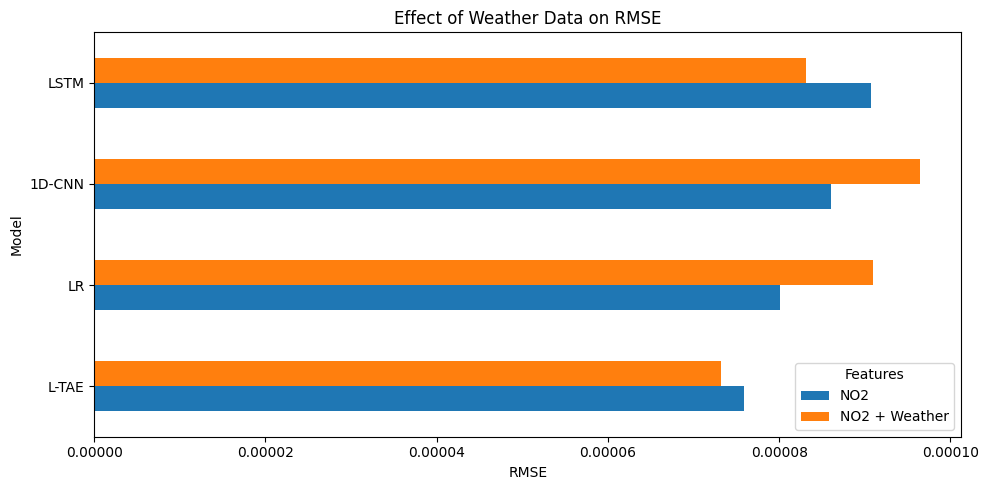

In [1920]:
pivot_rmse = results_table.pivot(
    index="Model",
    columns="Features",
    values="RMSE"
)

pivot_rmse = pivot_rmse.sort_values(by="NO2", ascending=True)

pivot_rmse.plot(kind="barh", figsize=(10,5))

plt.title("Effect of Weather Data on RMSE")
plt.xlabel("RMSE")

plt.tight_layout()
plt.show()

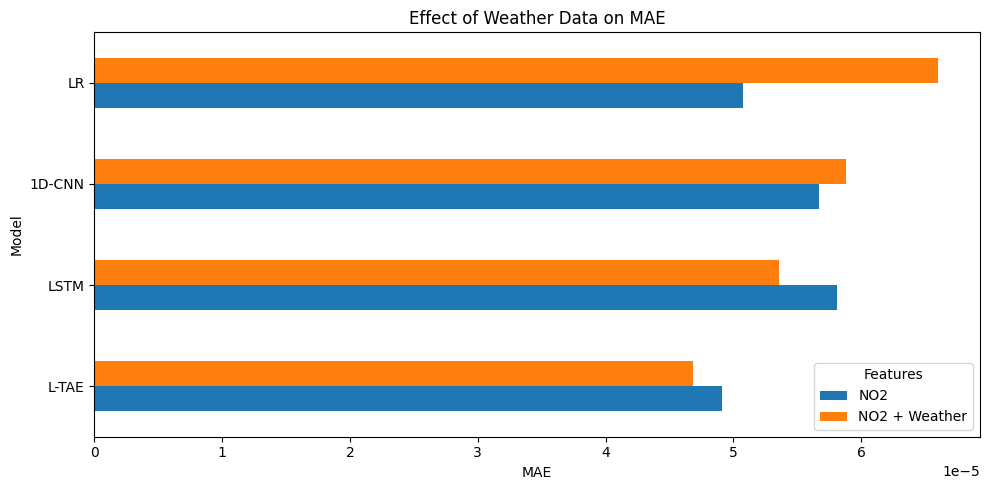

In [1921]:
pivot_mae = results_table.pivot(
    index="Model",
    columns="Features",
    values="MAE"
)

pivot_mae["avg"] = pivot_mae.mean(axis=1)
pivot_mae = pivot_mae.sort_values(by="avg", ascending=True)

pivot_mae.drop(columns="avg").plot(kind="barh", figsize=(10, 5))
plt.title("Effect of Weather Data on MAE")
plt.xlabel("MAE")
plt.tight_layout()
plt.show()

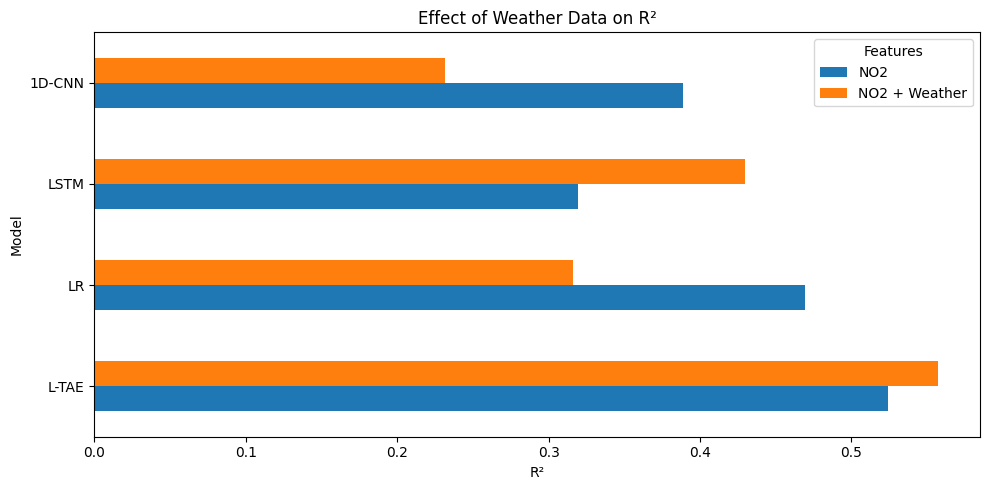

In [1922]:
pivot_r2 = results_table.pivot(
    index="Model",
    columns="Features",
    values="R2"
)

pivot_r2["avg"] = pivot_r2.mean(axis=1)
pivot_r2 = pivot_r2.sort_values(by="avg", ascending=False)

pivot_r2.drop(columns="avg").plot(kind="barh", figsize=(10, 5))
plt.title("Effect of Weather Data on R²")
plt.xlabel("R²")
plt.tight_layout()
plt.show()